In [14]:
import pandas as pd
import numpy as np

In [15]:
pd.read_csv('can_receive_logs\model3_C.csv')

,NUMBER,TIME_OFFSET,TYPE,ID,DLC,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,DATA_8,DELTA_TIME
0,1,4.913391,Rx,0000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.913391
1,2,4.914358,Rx,0370,8,12,01,08,1D,1F,BD,20,A7,0.000967
2,3,4.914639,Rx,0187,8,21,65,EA,00,60,EA,00,00,0.000281
3,4,4.914868,Rx,02D5,8,94,15,14,91,03,00,00,00,0.000229
4,5,4.915157,Rx,0186,8,8E,05,00,02,00,00,00,00,0.000289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599996,599997,196.512284,Rx,02D5,8,C3,4F,14,86,03,00,00,00,0.000247
599997,599998,196.512556,Rx,0186,8,3D,0F,00,02,00,97,0E,00,0.000272
599998,599999,196.512775,Rx,0385,8,70,6F,F7,80,00,00,D0,AE,0.000219
599999,600000,196.512920,Rx,038B,4,61,4D,20,00,NaN,NaN,NaN,NaN,0.000145


In [43]:
df = pd.read_csv('can_receive_logs/fuzz_model3/fuzz_model3_high.csv')

id_counts = df['ID'].value_counts(20)
id_counts.to_csv('id_counts.csv', header=True)

<Axes: title={'center': 'Top 20 Most Frequent IDs from Tesla Model 3 C-CAN'}, xlabel='ID'>

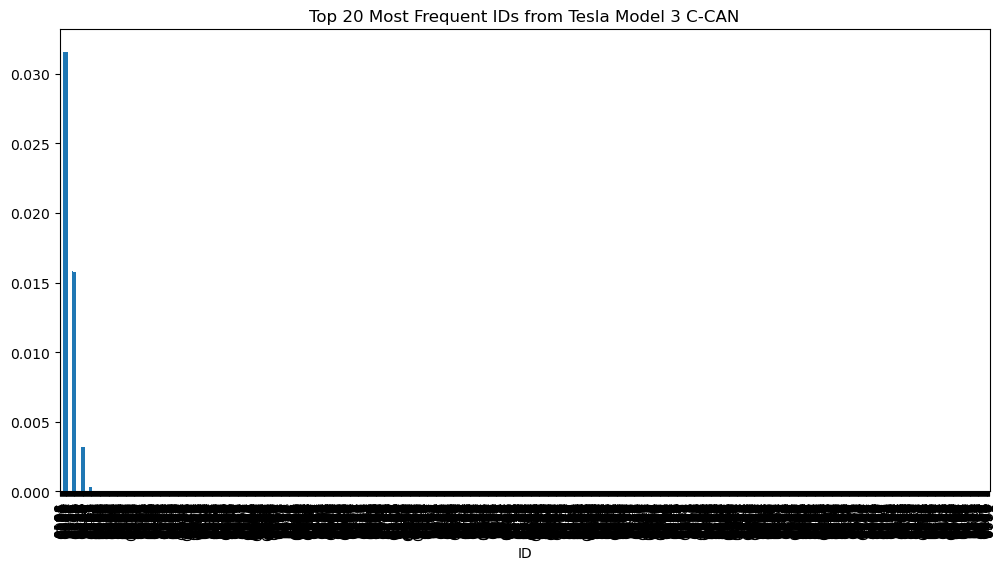

In [44]:
id_counts.plot(kind='bar', figsize=(12, 6), title='Top 20 Most Frequent IDs from Tesla Model 3 C-CAN')

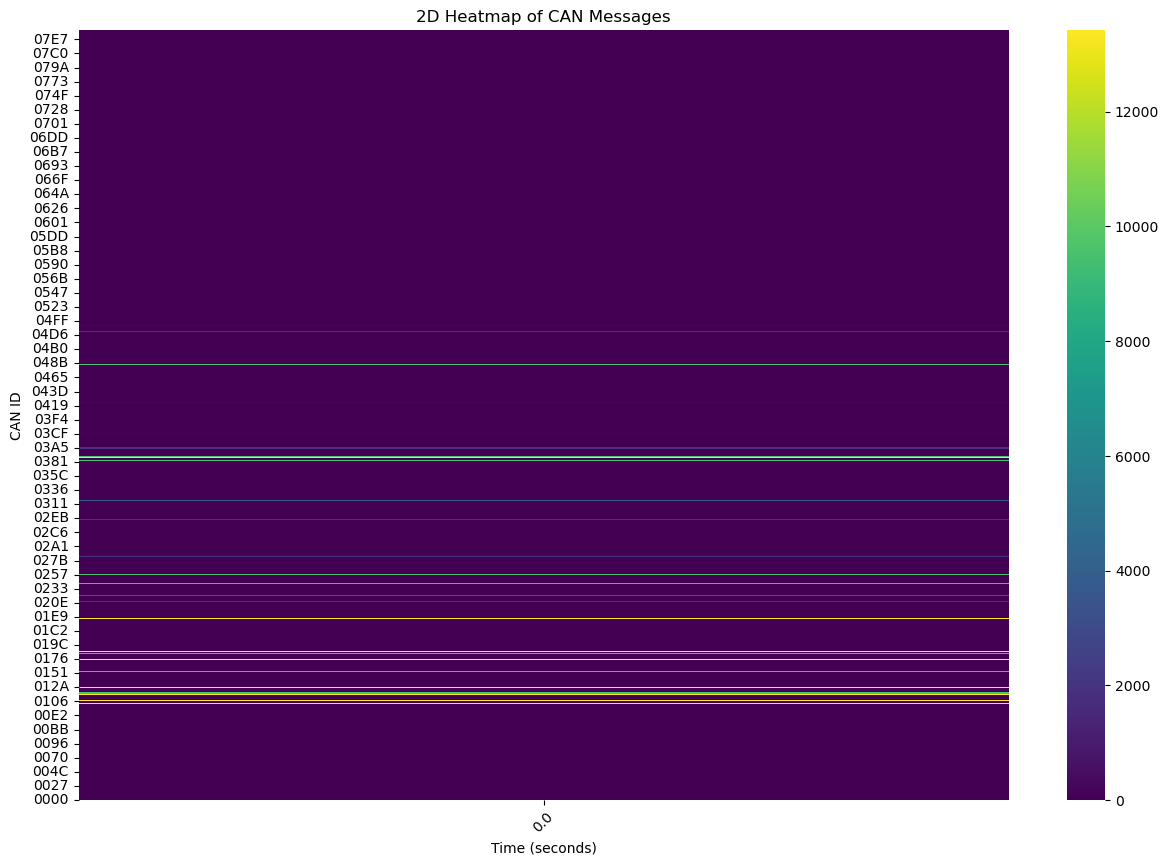

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert TIME_OFFSET to datetime format
df['TIME_OFFSET'] = pd.to_datetime(df['TIME_OFFSET'])

# 🔹 시간을 0.1초 단위로 구간화하여 binning (0.1초 단위 그룹화)
df['TIME_BIN'] = (df['TIME_OFFSET'].astype('int64') // 1e8) * 0.1  # 1e8 = 0.1초

# 🔹 피벗 테이블 생성 (TIME_BIN을 index로 사용)
pivot_table = df.pivot_table(index='TIME_BIN', columns='ID', aggfunc='size', fill_value=0)

# 🔹 히트맵 생성
plt.figure(figsize=(15, 10))
ax = sns.heatmap(pivot_table.T, cmap='viridis', vmin=0, vmax=pivot_table.values.max() * 0.7)

# 🔹 그래프 설정
plt.title('2D Heatmap of CAN Messages')
plt.xlabel('Time (seconds)')
plt.ylabel('CAN ID')
plt.xticks(rotation=45)  # X축 레이블 45도 회전
plt.gca().invert_yaxis()  # 🔹 Y축을 뒤집어서 CAN ID를 오름차순으로 정렬
plt.show()


C:\Users\fordr\AppData\Local\Temp\ipykernel_37048\401638620.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TIME_OFFSET'] = df['TIME_OFFSET'].astype(float)


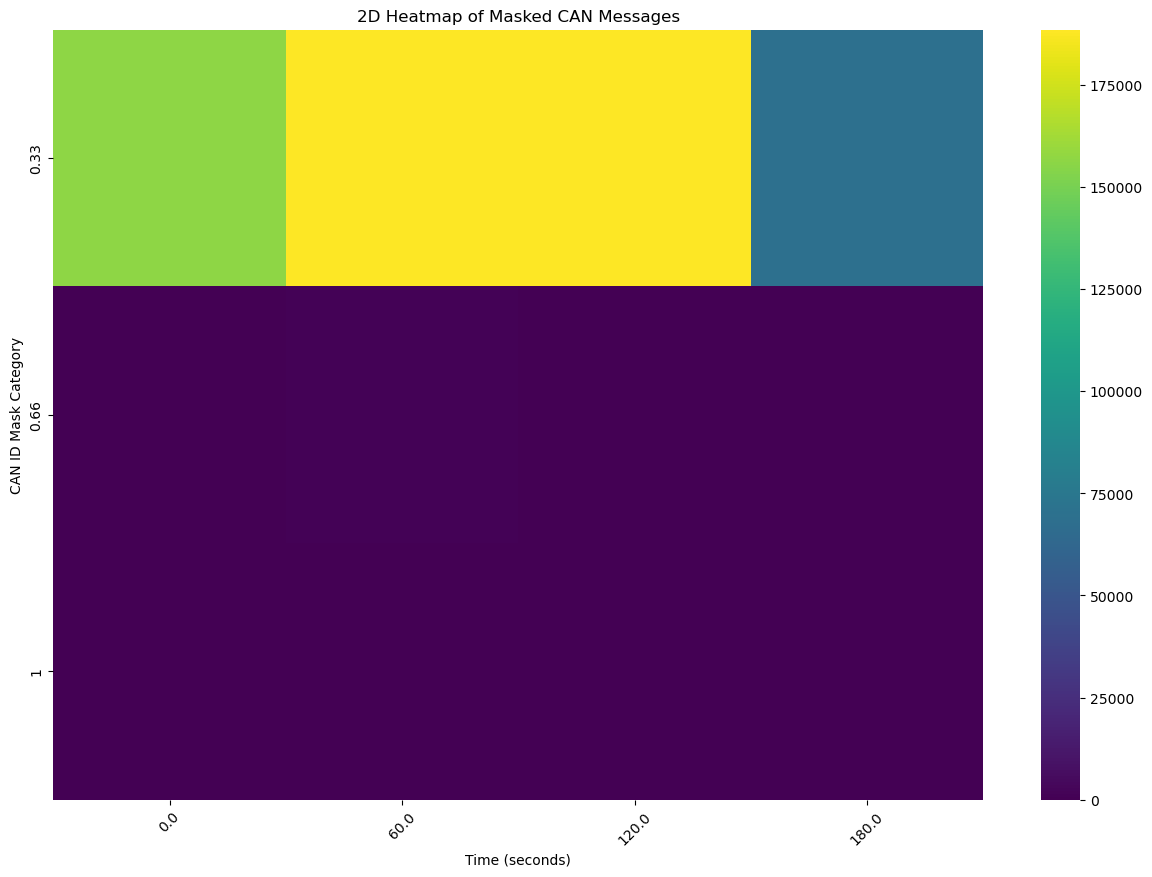

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read CSV File
def process_csv_file(file_path):
    data = pd.read_csv(file_path)
    data = data.iloc[:-1]  # Remove last row
    data = data.fillna(-1)  # Fill missing values
    return data

# Masking The CAN ID (Divide into 3 parts)
def divide_into_parts(hex_values, num_parts=3):
    part_size = len(hex_values) // num_parts
    remainder = len(hex_values) % num_parts
    parts = []
    
    start = 0
    for i in range(num_parts):
        end = start + part_size + (1 if i < remainder else 0)
        parts.append(hex_values[start:end])
        start = end

    return parts

# Convert CAN ID into Mask form
def categorize_can_ids_X(df, ID_G_1, ID_G_2, ID_G_3):
    mapping_dict = {**{can_id: '0.33' for can_id in ID_G_1},
                    **{can_id: '0.66' for can_id in ID_G_2},
                    **{can_id: '1' for can_id in ID_G_3}}
    
    df['Category'] = df['ID'].map(mapping_dict)
    df['Category'].fillna('Unknown', inplace=True)  # Handle unknown CAN IDs
    df = df[['TIME_OFFSET', 'ID', 'DELTA_TIME', 'Category']]
    
    return df

# Segmenting CAN Data into Time Intervals
def segment(df, time_gap=0.1):
    df = df[["TIME_OFFSET", "DELTA_TIME", "Category"]]
    
    # Convert TIME_OFFSET to float
    df['TIME_OFFSET'] = df['TIME_OFFSET'].astype(float)
    
    # Define time bins
    df['Time_Bin'] = (df['TIME_OFFSET'] // time_gap) * time_gap
    
    return df

# Load Data
file_path = "can_receive_logs/fuzz_model3/fuzz_model3_high.csv"  # Replace with your actual CSV file path
df = process_csv_file(file_path)

# Convert CAN_ID to groups
unique_can_ids = df['ID'].unique()
ID_G_1, ID_G_2, ID_G_3 = divide_into_parts(unique_can_ids)

# Apply masking
df = categorize_can_ids_X(df, ID_G_1, ID_G_2, ID_G_3)

# Segment time
df = segment(df, time_gap=60)

# Pivot Table for Heatmap
pivot_table = df.pivot_table(index="Time_Bin", columns="Category", aggfunc='size', fill_value=0)

# Plot Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(pivot_table.T, cmap='viridis')

plt.title('2D Heatmap of Masked CAN Messages')
plt.xlabel('Time (seconds)')
plt.ylabel('CAN ID Mask Category')
plt.xticks(rotation=45)
plt.show()


Category Distribution:
 Category
0.33    404517
0.66    191874
1         4262
Name: count, dtype: int64


C:\Users\fordr\AppData\Local\Temp\ipykernel_37048\1328047865.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TIME_OFFSET'] = df['TIME_OFFSET'].astype(float)


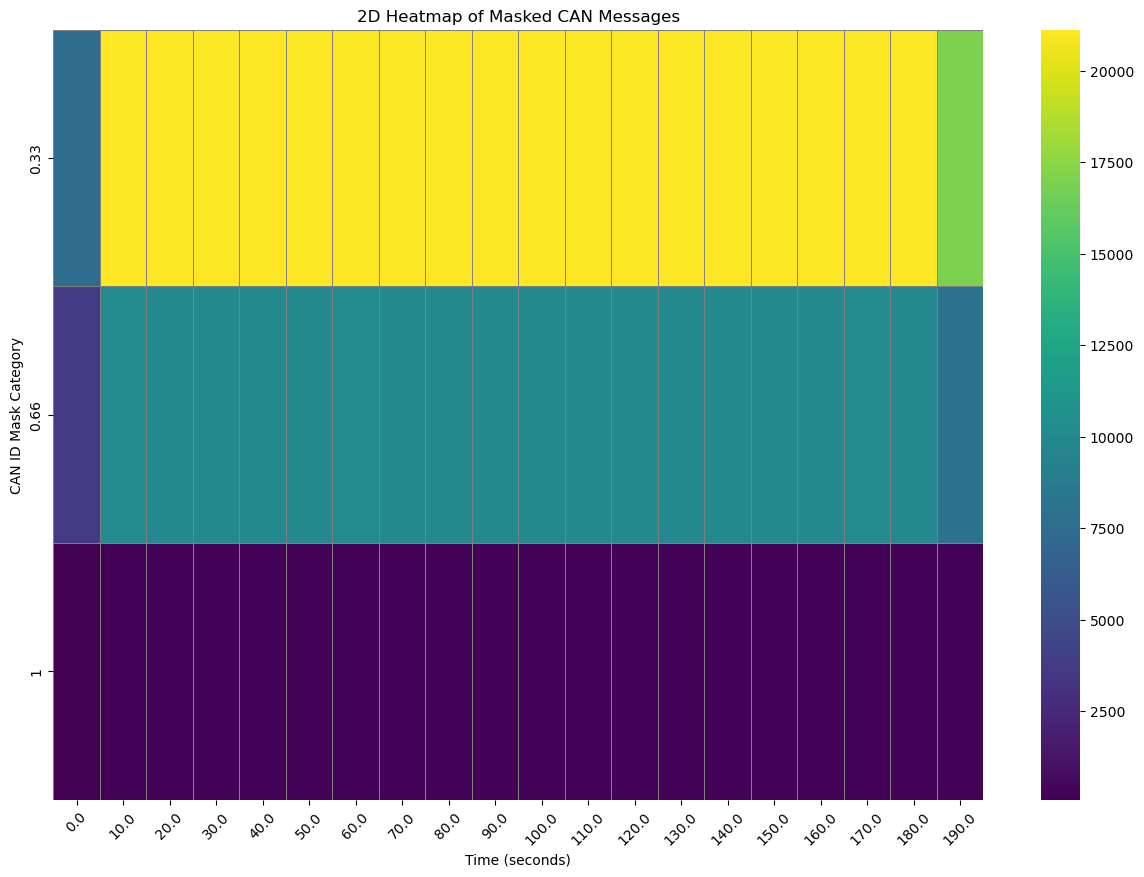

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read CSV File
def process_csv_file(file_path):
    data = pd.read_csv(file_path)
    data = data.iloc[:-1]  # Remove last row
    data = data.fillna(-1)  # Fill missing values
    return data

# Masking The CAN ID (Divide into 3 parts)
def divide_into_parts(hex_values, num_parts=3):
    hex_values = sorted(hex_values)  # Sort to keep similar values grouped
    part_size = len(hex_values) // num_parts
    remainder = len(hex_values) % num_parts
    parts = []
    
    start = 0
    for i in range(num_parts):
        end = start + part_size + (1 if i < remainder else 0)
        parts.append(hex_values[start:end])
        start = end

    return parts

# Convert CAN ID into Mask form
def categorize_can_ids_X(df, ID_G_1, ID_G_2, ID_G_3):
    mapping_dict = {**{can_id: '0.33' for can_id in ID_G_1},
                    **{can_id: '0.66' for can_id in ID_G_2},
                    **{can_id: '1' for can_id in ID_G_3}}
    
    df['Category'] = df['ID'].map(mapping_dict)
    df['Category'].fillna('Unknown', inplace=True)  # Handle unknown CAN IDs
    df = df[['TIME_OFFSET', 'ID', 'DELTA_TIME', 'Category']]
    
    return df

# Segmenting CAN Data into Time Intervals
def segment(df, time_gap=0.5):  # 🔹 time_gap을 0.5초로 설정하여 더 명확한 시각화
    df = df[["TIME_OFFSET", "DELTA_TIME", "Category"]]
    
    # Convert TIME_OFFSET to float
    df['TIME_OFFSET'] = df['TIME_OFFSET'].astype(float)
    
    # Define time bins
    df['Time_Bin'] = (df['TIME_OFFSET'] // time_gap) * time_gap
    
    return df

# Load Data
file_path = "can_receive_logs/fuzz_model3/fuzz_model3_medium.csv"  # Replace with your actual CSV file path
df = process_csv_file(file_path)

# Convert CAN_ID to groups
unique_can_ids = df['ID'].unique()
ID_G_1, ID_G_2, ID_G_3 = divide_into_parts(unique_can_ids)

# Apply masking
df = categorize_can_ids_X(df, ID_G_1, ID_G_2, ID_G_3)

# Check Category distribution
print("Category Distribution:\n", df['Category'].value_counts())

# Segment time
df = segment(df, time_gap=10)  # 🔹 시간 간격을 0.5초로 설정하여 그룹화

# Pivot Table for Heatmap
pivot_table = df.pivot_table(index="Time_Bin", columns="Category", aggfunc='size', fill_value=0)

# 🔹 빈 카테고리는 제외하여 시각적으로 불필요한 요소 제거
pivot_table = pivot_table.loc[:, (pivot_table != 0).any(axis=0)]

# Plot Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(pivot_table.T, cmap='viridis', linewidths=0.5, linecolor='gray')

plt.title('2D Heatmap of Masked CAN Messages')
plt.xlabel('Time (seconds)')
plt.ylabel('CAN ID Mask Category')
plt.xticks(rotation=45)
plt.show()


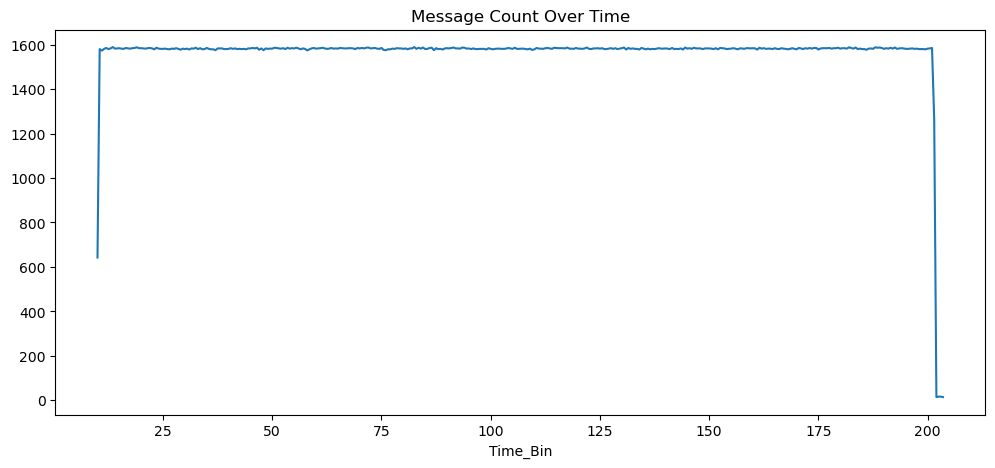

In [36]:
import matplotlib.pyplot as plt
df.groupby('Time_Bin').size().plot(kind='line', figsize=(12, 5), title='Message Count Over Time')
plt.show()


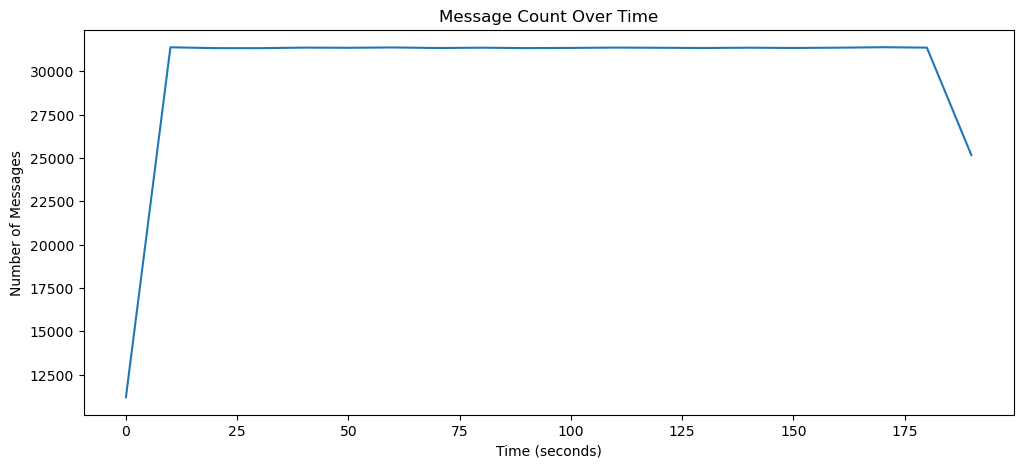

In [40]:
import matplotlib.pyplot as plt

# 시간별 메시지 개수 확인
df.groupby('Time_Bin').size().plot(kind='line', figsize=(12, 5), title='Message Count Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Messages')
plt.show()

In [ ]:
print("Category Distribution:\n", df['Category'].value_counts())

Category Distribution:
 Category
0.33    404517
0.66    191874
1         4262
Name: count, dtype: int64


C:\Users\fordr\AppData\Local\Temp\ipykernel_37048\524427144.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TIME_OFFSET'] = df['TIME_OFFSET'].astype(float)


Category         0.33        0.66           1
count      388.000000  388.000000  388.000000
mean      1087.587629  464.842784   10.494845
std        116.107164   49.285474    2.087857
min          2.000000    5.000000    2.000000
25%       1100.000000  469.000000    9.000000
50%       1101.000000  471.000000   11.000000
75%       1103.000000  472.000000   12.000000
max       1108.000000  478.000000   16.000000


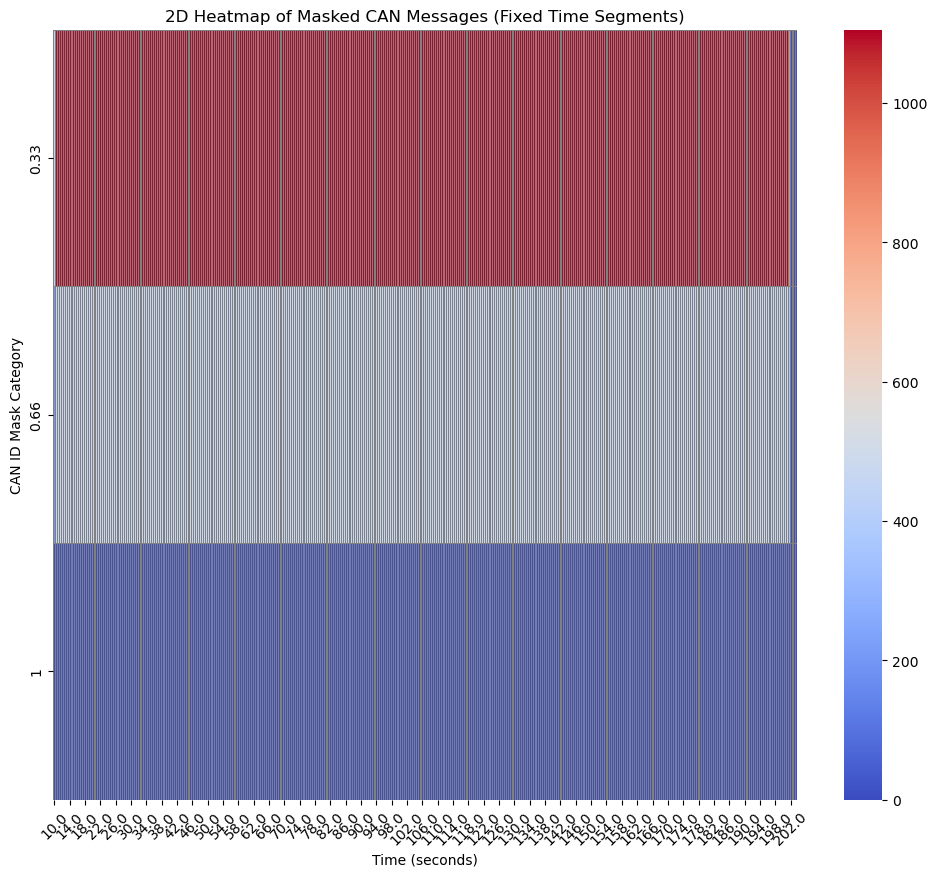

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read CSV File
def process_csv_file(file_path):
    data = pd.read_csv(file_path)
    data = data.iloc[:-1]  # Remove last row
    data = data.fillna(-1)  # Fill missing values
    return data

# CAN ID 그룹 나누기
def divide_into_parts(hex_values, num_parts=3):
    hex_values = sorted(hex_values)
    part_size = len(hex_values) // num_parts
    remainder = len(hex_values) % num_parts
    parts = []
    
    start = 0
    for i in range(num_parts):
        end = start + part_size + (1 if i < remainder else 0)
        parts.append(hex_values[start:end])
        start = end

    return parts

# CAN ID를 3개 그룹으로 변환
def categorize_can_ids_X(df, ID_G_1, ID_G_2, ID_G_3):
    mapping_dict = {**{can_id: '0.33' for can_id in ID_G_1},
                    **{can_id: '0.66' for can_id in ID_G_2},
                    **{can_id: '1' for can_id in ID_G_3}}
    
    df['Category'] = df['ID'].map(mapping_dict)
    df['Category'].fillna('Unknown', inplace=True)
    df = df[['TIME_OFFSET', 'ID', 'DELTA_TIME', 'Category']]
    
    return df

# 일정 간격으로 타임스탬프 그룹화
def segment(df, time_gap=0.5):
    df = df[["TIME_OFFSET", "DELTA_TIME", "Category"]]
    
    df['TIME_OFFSET'] = df['TIME_OFFSET'].astype(float)

    # 일정 간격 유지
    df['Time_Bin'] = (df['TIME_OFFSET'] // time_gap) * time_gap
    
    return df

# Load Data
file_path = "can_receive_logs/fuzz_model3/fuzz_model3_high.csv"
df = process_csv_file(file_path)

# Convert CAN_ID to groups
unique_can_ids = df['ID'].unique()
ID_G_1, ID_G_2, ID_G_3 = divide_into_parts(unique_can_ids)

# Apply masking
df = categorize_can_ids_X(df, ID_G_1, ID_G_2, ID_G_3)

# Segment time (Fixed Interval)
df = segment(df, time_gap=0.5)

# Pivot Table for Heatmap
pivot_table = df.pivot_table(index="Time_Bin", columns="Category", aggfunc='size', fill_value=0)

# 🔹 데이터 범위 확인 (빈 데이터 방지)
print(pivot_table.describe())

# 🔹 색 대비 조정하여 회색 문제 해결
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table.T, cmap="coolwarm", vmin=0, vmax=np.percentile(pivot_table.values, 99), linewidths=0.5, linecolor="gray")

plt.title('2D Heatmap of Masked CAN Messages (Fixed Time Segments)')
plt.xlabel('Time (seconds)')
plt.ylabel('CAN ID Mask Category')
plt.xticks(rotation=45)
plt.show()
